In [24]:
import matplotlib.pyplot as plt
import numpy as np
import qiskit_aer
import scipy.constants as constants
from qiskit import transpile
from qiskit.circuit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, partial_trace
from qiskit_aer_encore.simulator import generate_aer_simulator
from qiskit_hamiltonian_simulation.time_independent.direct import (
    MomentumDomainEvolutionQuadratic,
    PositionDomainEvolutionQuadratic,
)
from qiskit_hamiltonian_simulation.time_independent.sample_based import (
    KineticEvolutionSampleBased,
    PotentialEvolutionSampleBased,
)
from qiskit_phase_propagator.sample_based import (
    QuadraticSignalSampleBasedPhasePropagator,
)
from qiskit_signals.helper_types import EncodingType
from qiskit_signals.quantum_axis import (
    AngularWavenumberAxis,
    MomentumAxis,
    PositionAxis,
)
from qiskit_signals.quantum_signal import GenericQuantumSignal, QuadraticQuantumSignal
from qiskit_signals.sample_based_signal import ArbitrarySignalForSampleBasedProtocol
from wave_optics_propagation.elements import (
    free_space_signal_generator,
    radius_of_convex_planar_lens_as_a_func_of_z,
    thin_lens_signal_generator,
    thin_transparent_plate_signal_generator,
)
from wave_optics_propagation.visualization import plot_wavefunction

---


### Initial parameters


In [25]:
# beam parameters
vacuum_wavelength = 1e-6  # 1 micron
beam_FWHM = 5e-3  # 5 mm

# lens parameters
focal_length = 200  # 200 mm
lens_diameter = 25e-3  # 25 mm
refractive_index = 1.5  # typical glass
lens_thickness = 0.001  # 1 mm

# free space propagation parameters
propagation_after_lens = 1.5 * focal_length  # 1.5 times focal length

# simulation parameters
transverse_length = 0.10  # 10 cm, transverse simulation window
num_of_steps_after_lens = 40
lens_slices = 20
num_qubits = 8
max_delta = 0.1

### Constants


In [26]:
c = constants.c
# hbar = constants.hbar

### Derived parameters


In [27]:
k_0 = 2 * constants.pi / vacuum_wavelength

dimension = 2**num_qubits
delta_x = transverse_length / dimension

gaussian_mean = transverse_length / 2
gaussian_beam_waist = beam_FWHM / (np.sqrt(2 * np.log(2)))
gaussian_sigma = gaussian_beam_waist / np.sqrt(2)

vacuum_rayleigh_length = (np.pi * gaussian_beam_waist**2) / vacuum_wavelength


### Derived objects


In [28]:
lens_slice_positions = np.linspace(0, lens_thickness, lens_slices, endpoint=False)
lens_slice_thickness = lens_thickness / lens_slices

step_size_after_lens = propagation_after_lens / num_of_steps_after_lens

lens_lengths = [
    radius_of_convex_planar_lens_as_a_func_of_z(focal_length, z, lens_thickness)
    for z in lens_slice_positions
]
# lens_lengths

### Approximations checks


In [29]:
assert (
    gaussian_beam_waist > 10 * vacuum_wavelength
)  # ensure paraxial approximation validity

### Axes


In [30]:
x_axis = PositionAxis(
    num_qubits=num_qubits, delta_x=delta_x, encoding=EncodingType.UNSIGNED
)
k_axis = AngularWavenumberAxis.from_position_axis(x_axis)
# p_axis = MomentumAxis.from_position_axis(x_axis, hbar=hbar)

### Initial beam profile


602833.9315279227


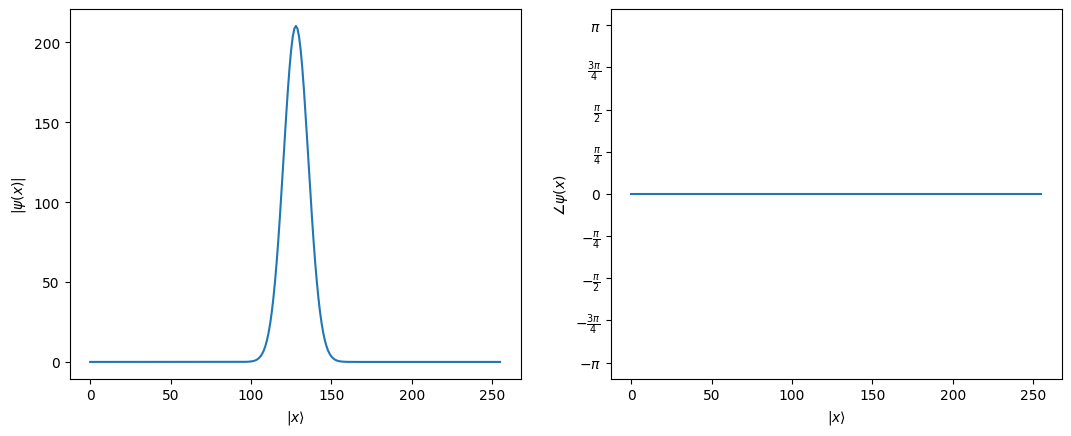

In [42]:
def psi_signal_function(x):
    norm_factor = 1 / (gaussian_sigma * (2 * constants.pi) ** 0.25)
    return norm_factor * np.exp(-(((x - gaussian_mean) / gaussian_beam_waist) ** 2))


# def psi_signal_function(x):
#     return np.where(
#         (x > 1 / 3) & (x < 2 / 3),
#         1,
#         0,
#     )


# def psi_signal_function(x):
#     signal = np.zeros(dimension)
#     middle = dimension // 2
#     signal[middle - 20 : middle - 15] = 1
#     signal[middle + 15 : middle + 20] = 1
#     return signal

# psi_flat = Statevector.from_label("+" * num_qubits)

psi = GenericQuantumSignal(x_axis, psi_signal_function)

print(np.linalg.norm(psi.data) ** 2)
plot_wavefunction(psi.data, normalize=False)


### Lens potentials


In [32]:
for i, lens_length in enumerate(lens_lengths):
    lens_signal = thin_transparent_plate_signal_generator(
        x_axis=x_axis,
        refractive_index=refractive_index,
        thickness=lens_slice_thickness,
        radius=lens_length,
        wavelength=vacuum_wavelength,
        scale_down=True,
    )
    # plot_wavefunction(lens_signal.data, normalize=False)

---


In [33]:
psi_reg = QuantumRegister(num_qubits, name=r"\psi")
phi_reg = QuantumRegister(num_qubits, name=r"\phi")
success_flag = ClassicalRegister(num_qubits, name="success_flag")
circuit = QuantumCircuit(psi_reg, phi_reg, success_flag)
# circuit = QuantumCircuit(psi_reg)

circuit.initialize(psi.data.tolist() / np.linalg.norm(psi.data), psi_reg)
# circuit.initialize(psi_flat, psi_reg)

circuit.save_statevector(label=f"step_{0}")  # type: ignore

### Lens
for i, lens_length in enumerate(lens_lengths):
    print(f"Doing lens slice {i + 1}/{lens_slices}")

    # lens_signal = thin_transparent_plate_signal_generator(
    #     x_axis=x_axis,
    #     refractive_index=refractive_index,
    #     thickness=lens_slice_thickness,
    #     radius=lens_length,
    #     wavelength=wavelength,
    # )
    # sample_based_lens_signal = (
    #     ArbitrarySignalForSampleBasedProtocol.from_generic_signal(lens_signal)
    # )
    # print(np.max(np.abs(sample_based_lens_signal.data)))
    # print(np.sum(np.abs(sample_based_lens_signal.data) ** 2))
    # # continue
    # lens = QuadraticSignalSampleBasedPhasePropagator(
    #     signal=sample_based_lens_signal, max_delta=max_delta
    # )
    # print(f"had {lens.num_of_cycles} cycles")

    # circuit.compose(
    #     lens,
    #     circuit.qubits,
    #     circuit.clbits,
    #     inplace=True,
    # )

    # propagator_signal = free_space_signal_generator(
    #     k_axis=k_axis,
    #     delta_t=lens_slice_thickness / c,
    #     wavelength=wavelength,
    #     c=constants.c,
    # )
    # propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    # circuit.compose(
    #     propagator,
    #     psi_reg,
    #     inplace=True,
    # )
    # circuit.save_statevector(label=f"step_lens_{i}")  # type: ignore


for i in range(num_of_steps_after_lens):
    print(f"Doing free space step {i + 1}/{num_of_steps_after_lens}")

    propagator_signal = free_space_signal_generator(
        k_axis=k_axis,
        delta_t=step_size_after_lens / c,
        wavelength=vacuum_wavelength,
        c=constants.c,
    )
    propagator = MomentumDomainEvolutionQuadratic(quadratic_signal=propagator_signal)

    circuit.compose(
        propagator,
        psi_reg,
        inplace=True,
    )
    circuit.save_statevector(label=f"step_after_lens_{i + 1}")  # type: ignore

Doing lens slice 1/20
Doing lens slice 2/20
Doing lens slice 3/20
Doing lens slice 4/20
Doing lens slice 5/20
Doing lens slice 6/20
Doing lens slice 7/20
Doing lens slice 8/20
Doing lens slice 9/20
Doing lens slice 10/20
Doing lens slice 11/20
Doing lens slice 12/20
Doing lens slice 13/20
Doing lens slice 14/20
Doing lens slice 15/20
Doing lens slice 16/20
Doing lens slice 17/20
Doing lens slice 18/20
Doing lens slice 19/20
Doing lens slice 20/20
Doing free space step 1/40
Doing free space step 2/40
Doing free space step 3/40
Doing free space step 4/40
Doing free space step 5/40
Doing free space step 6/40
Doing free space step 7/40
Doing free space step 8/40
Doing free space step 9/40
Doing free space step 10/40
Doing free space step 11/40
Doing free space step 12/40
Doing free space step 13/40
Doing free space step 14/40
Doing free space step 15/40
Doing free space step 16/40
Doing free space step 17/40
Doing free space step 18/40
Doing free space step 19/40
Doing free space step 20/4

In [34]:
simulator = generate_aer_simulator()
transpiled_circuit = transpile(circuit, simulator)
job = simulator.run(transpiled_circuit, shots=1)

In [35]:
result = job.result()
data = result.data()

In [36]:
# counts = result.get_counts().int_outcomes()
# assert counts[0] == 1

In [37]:
# def process_statevector(statevector):
#     return statevector
def process_statevector(statevector):
    """Process the statevector to extract position probabilities."""
    n = statevector.num_qubits
    rho = partial_trace(statevector, np.arange(int(n // 2), n).tolist())
    reduced_state = rho.to_statevector()

    return reduced_state


initial_statevector = process_statevector(data[f"step_{0}"])

lens_statevectors = [
    process_statevector(data[f"step_lens_{i}"]) if f"step_lens_{i}" in data else None
    for i in range(lens_slices)
]
after_lens_statevectors = [
    process_statevector(data[f"step_after_lens_{i + 1}"])
    if f"step_after_lens_{i + 1}" in data
    else None
    for i in range(num_of_steps_after_lens)
]

Plotting initial state


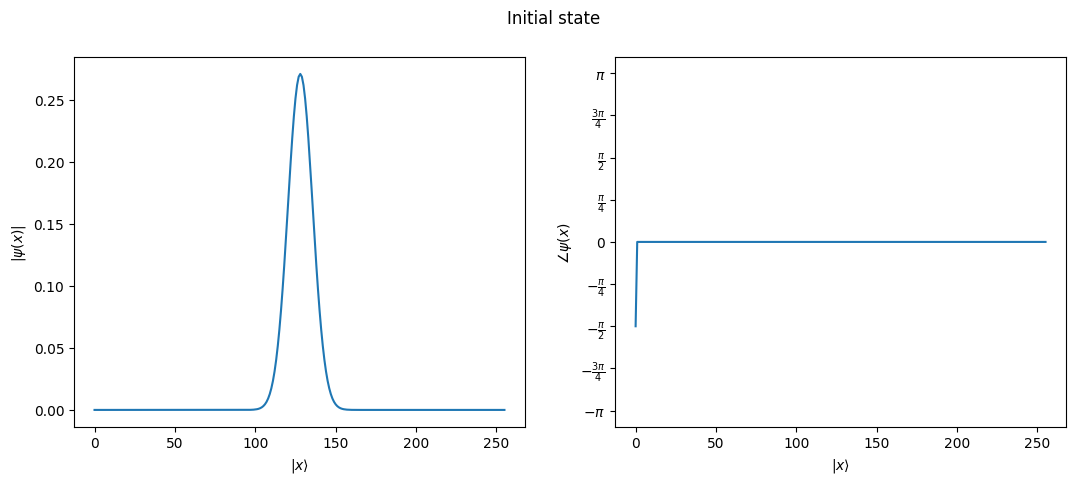

Plotting free space step 1/40


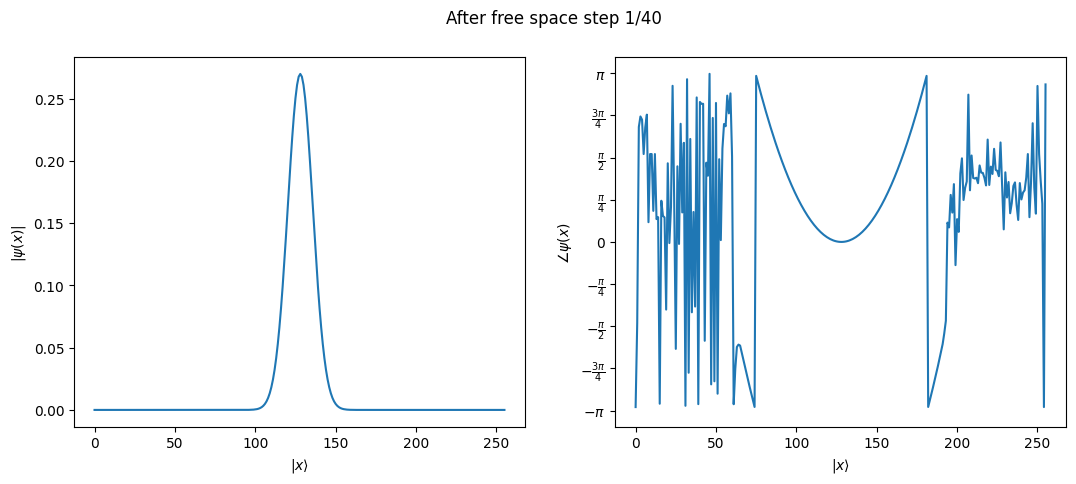

Plotting free space step 2/40


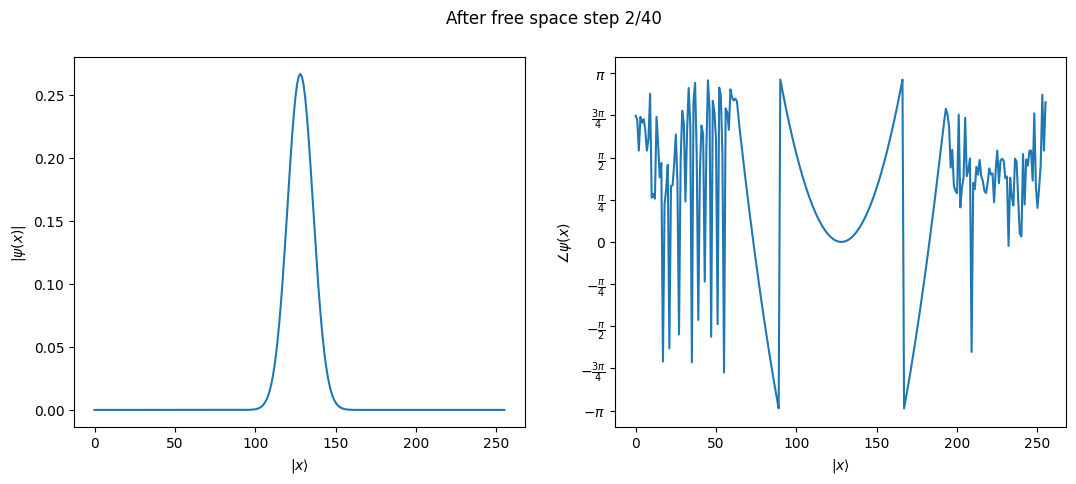

Plotting free space step 3/40


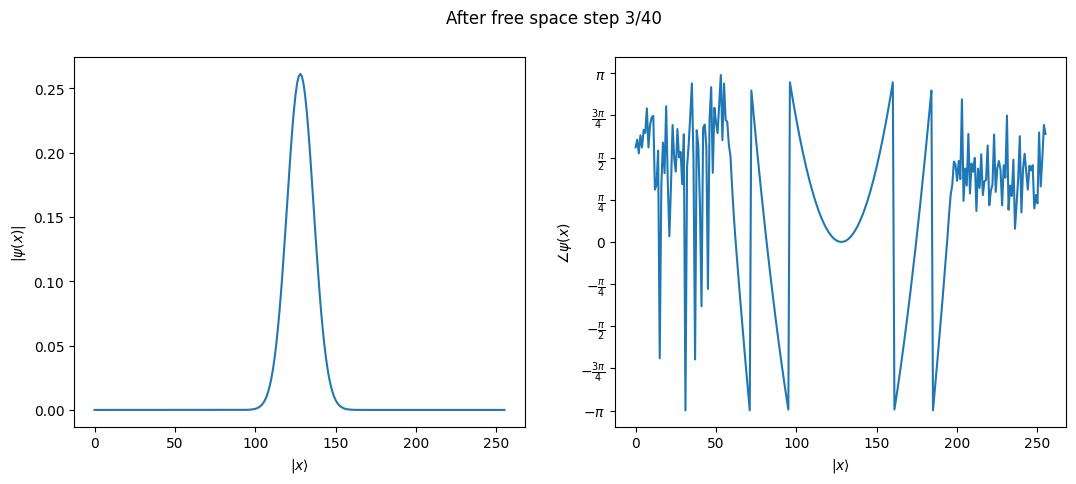

Plotting free space step 4/40


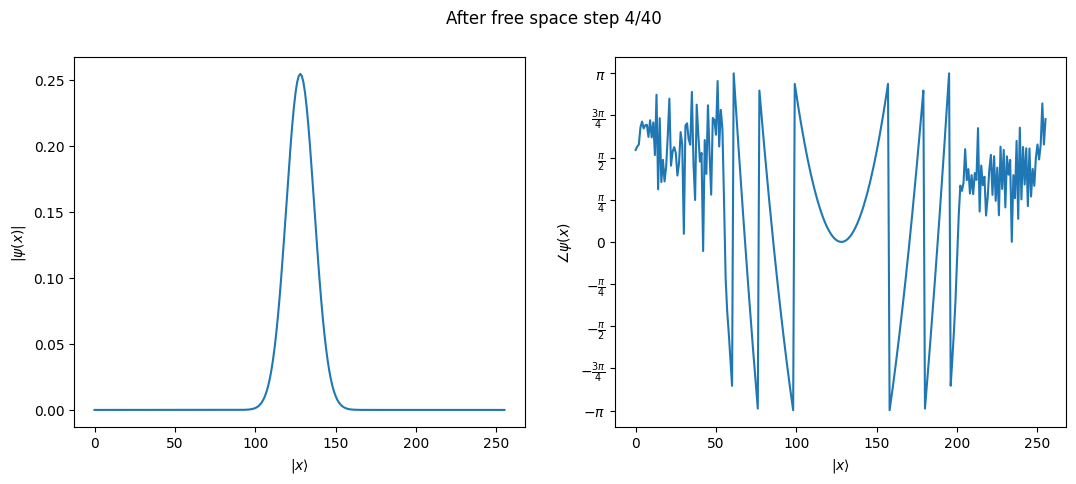

Plotting free space step 5/40


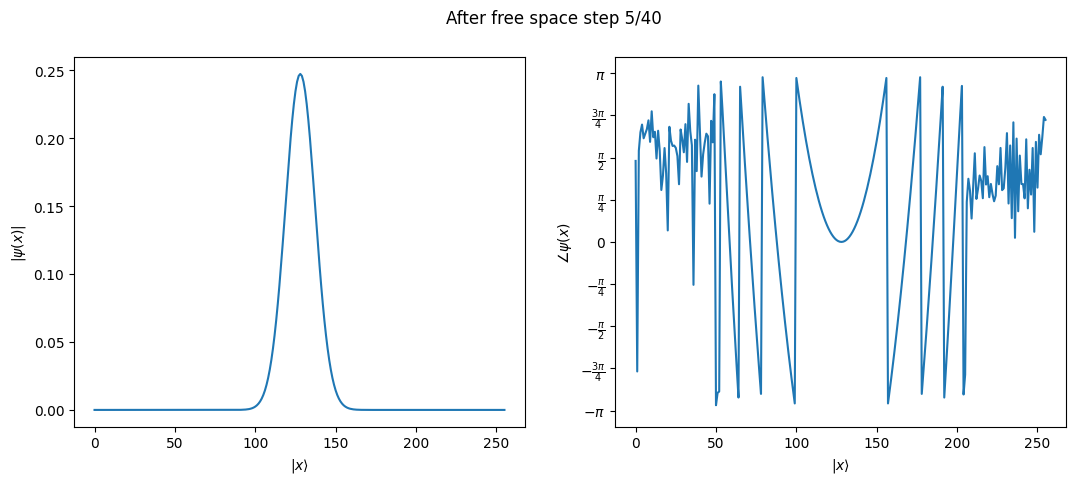

Plotting free space step 6/40


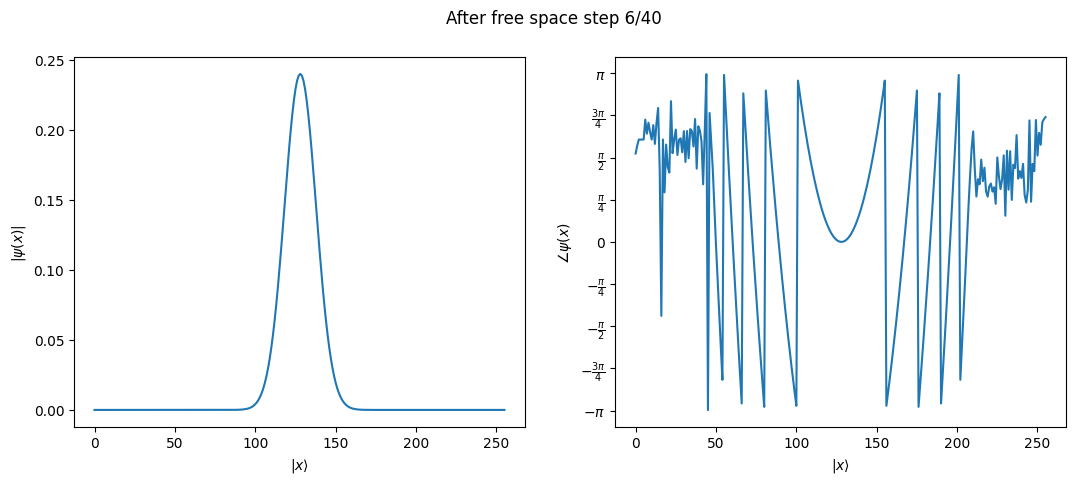

Plotting free space step 7/40


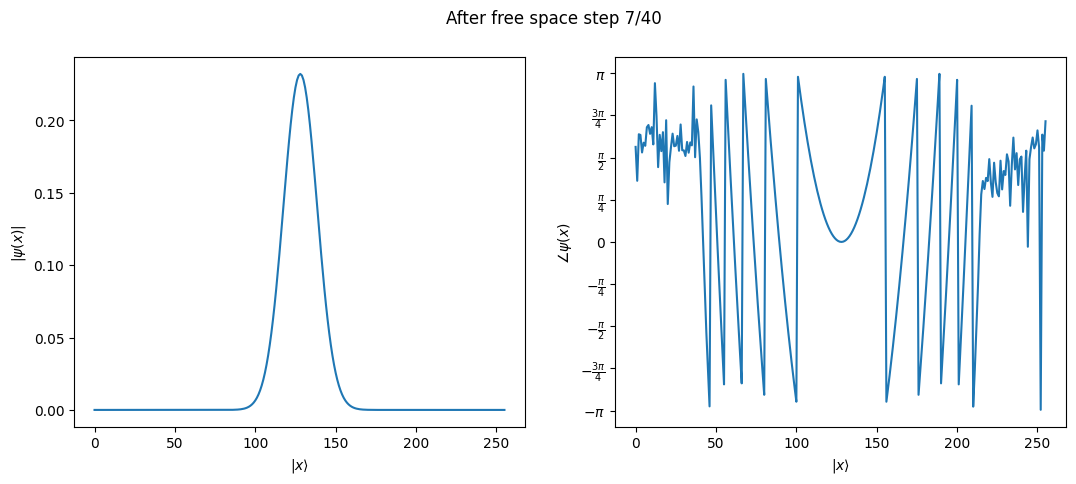

Plotting free space step 8/40


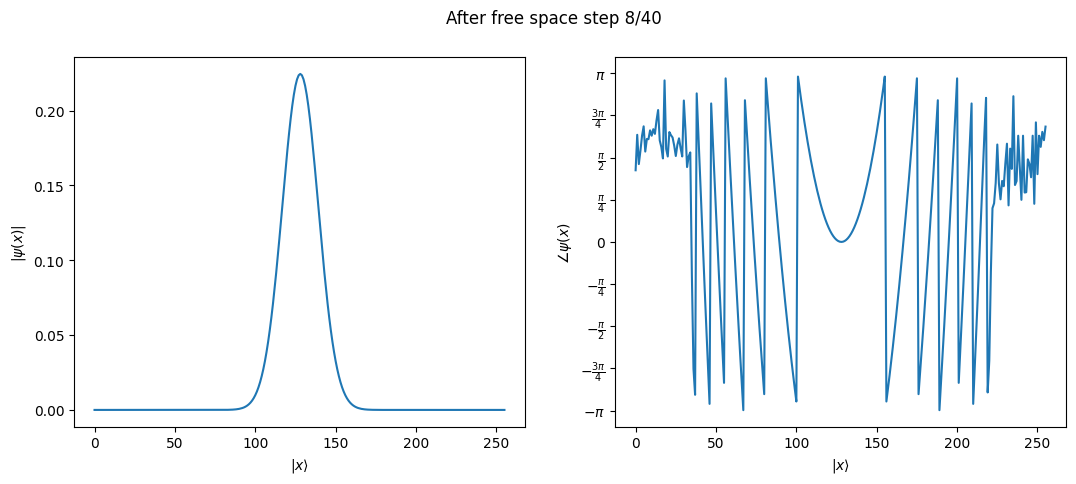

Plotting free space step 9/40


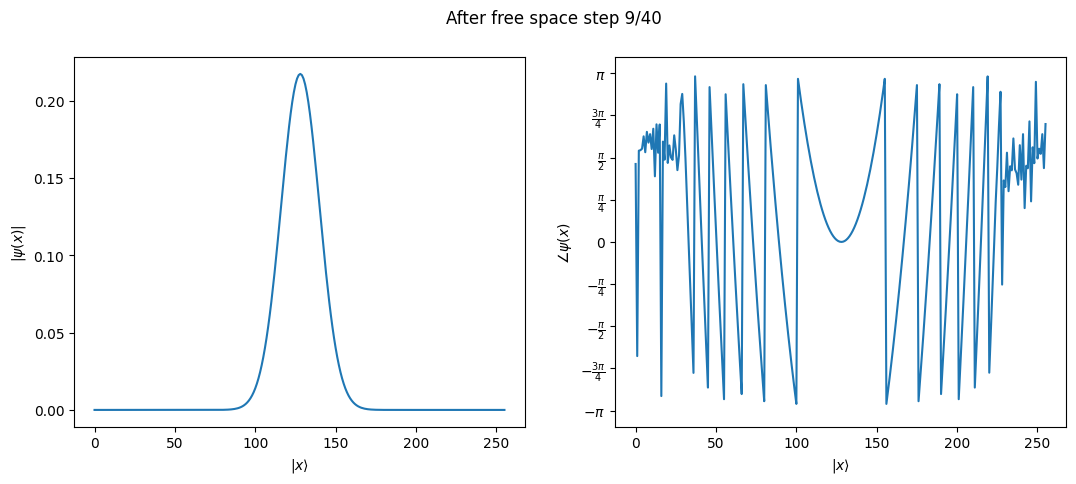

Plotting free space step 10/40


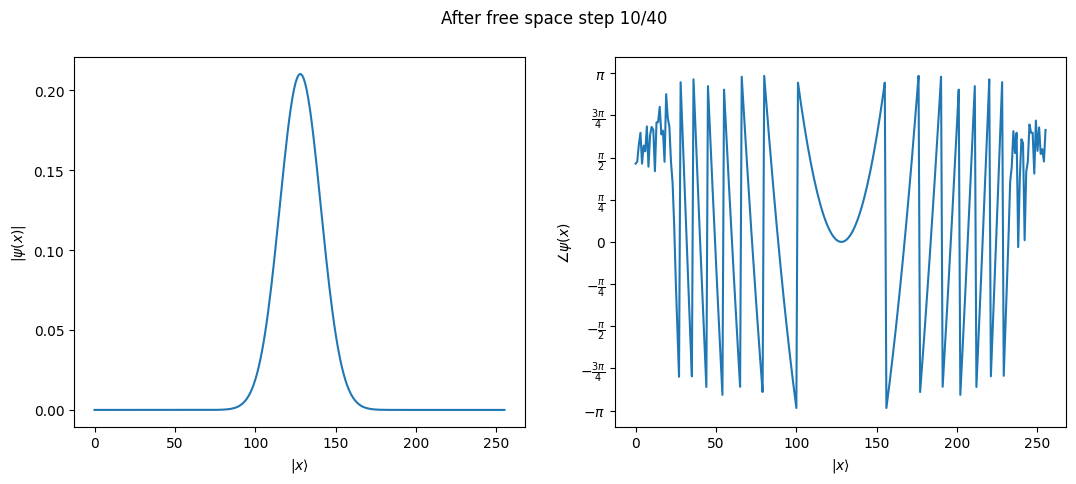

Plotting free space step 11/40


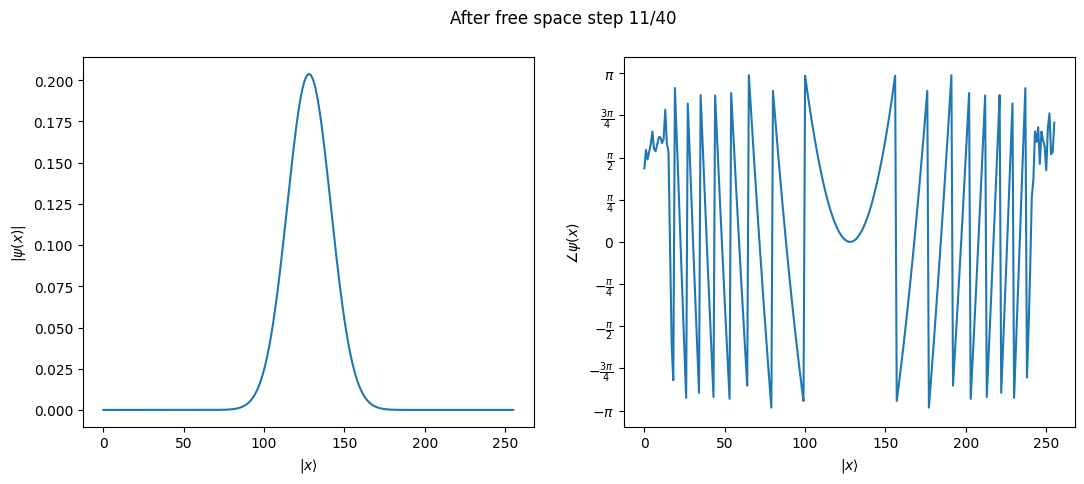

Plotting free space step 12/40


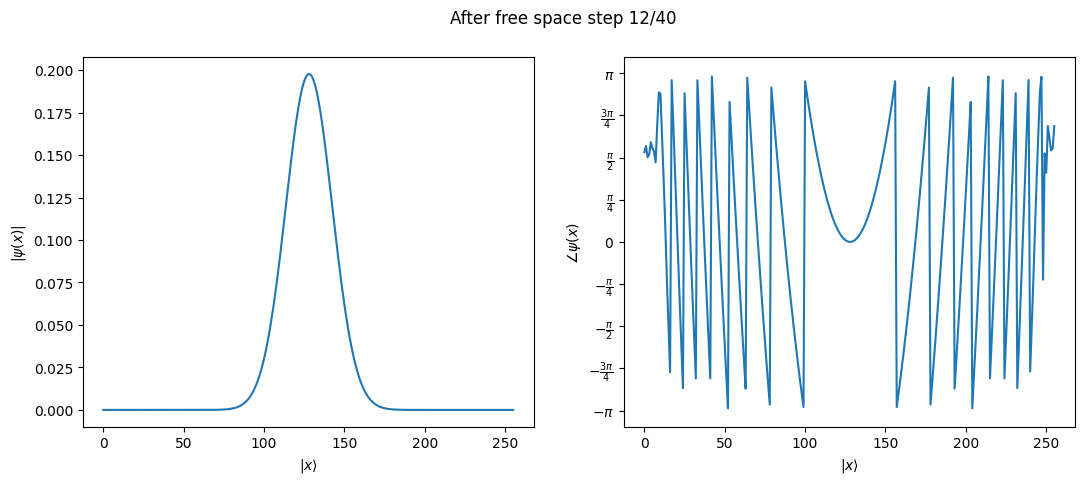

Plotting free space step 13/40


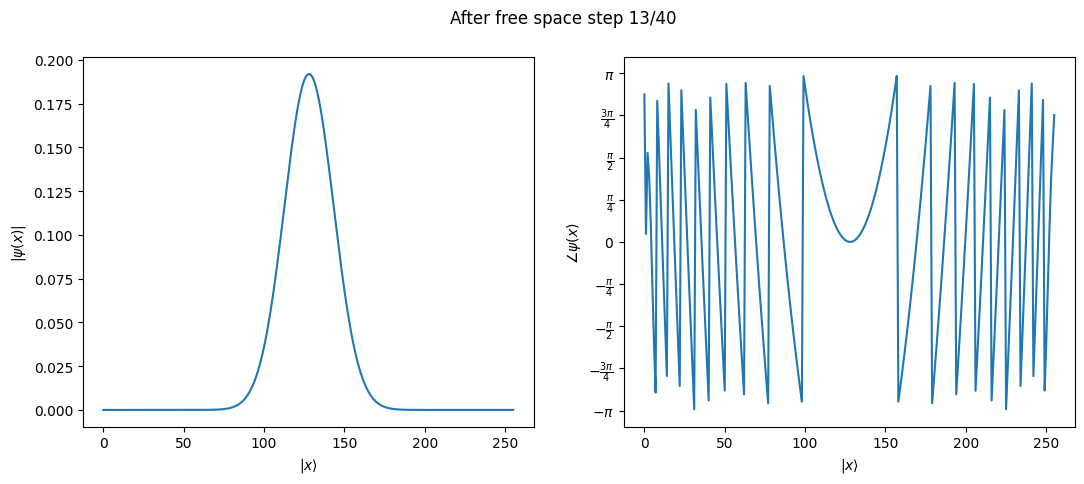

Plotting free space step 14/40


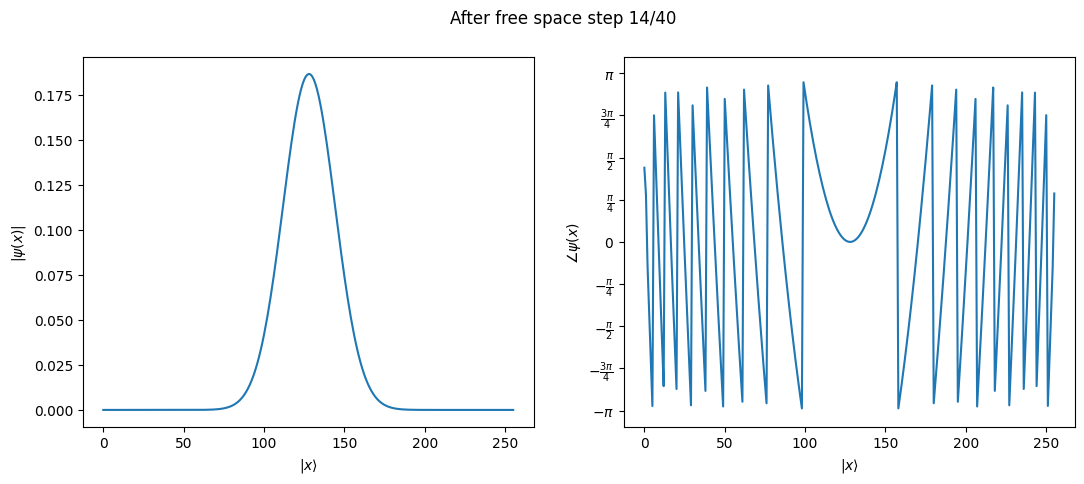

Plotting free space step 15/40


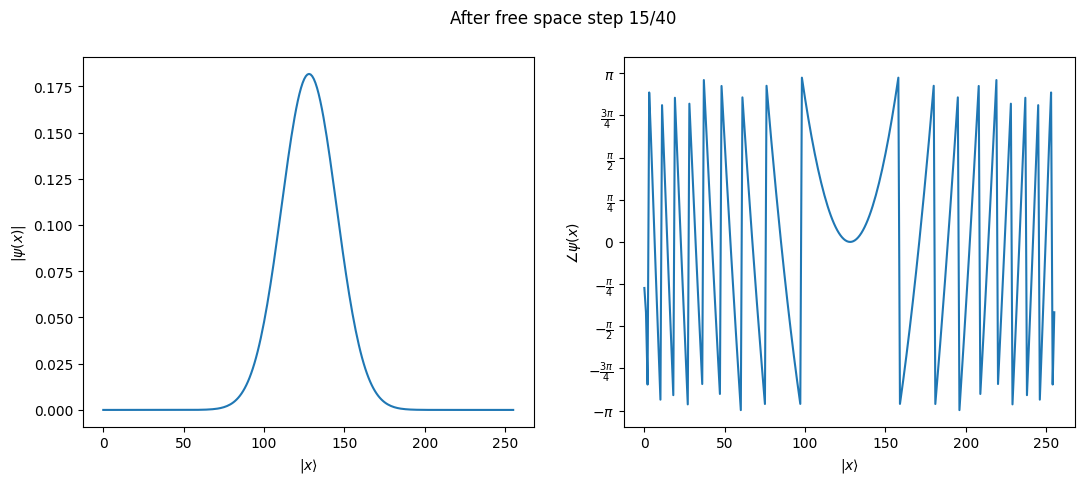

Plotting free space step 16/40


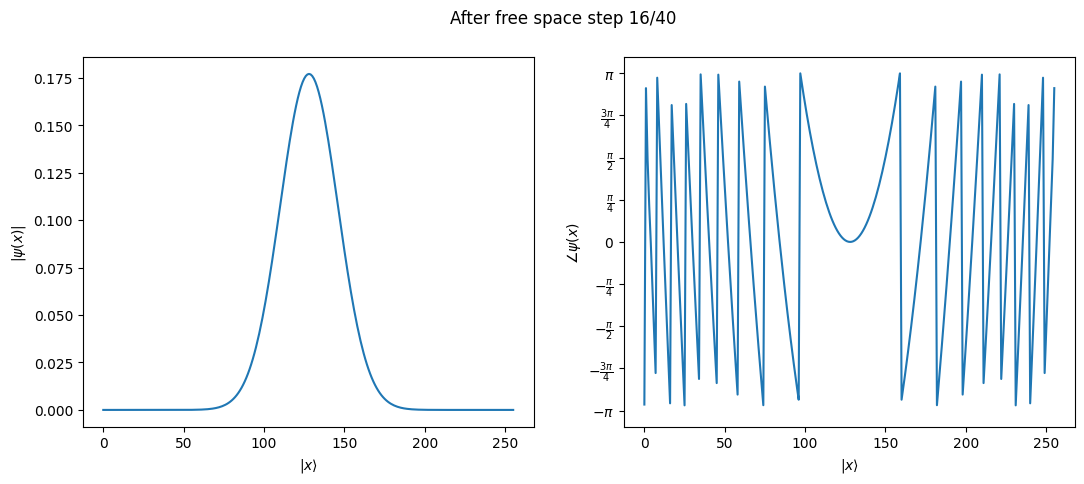

Plotting free space step 17/40


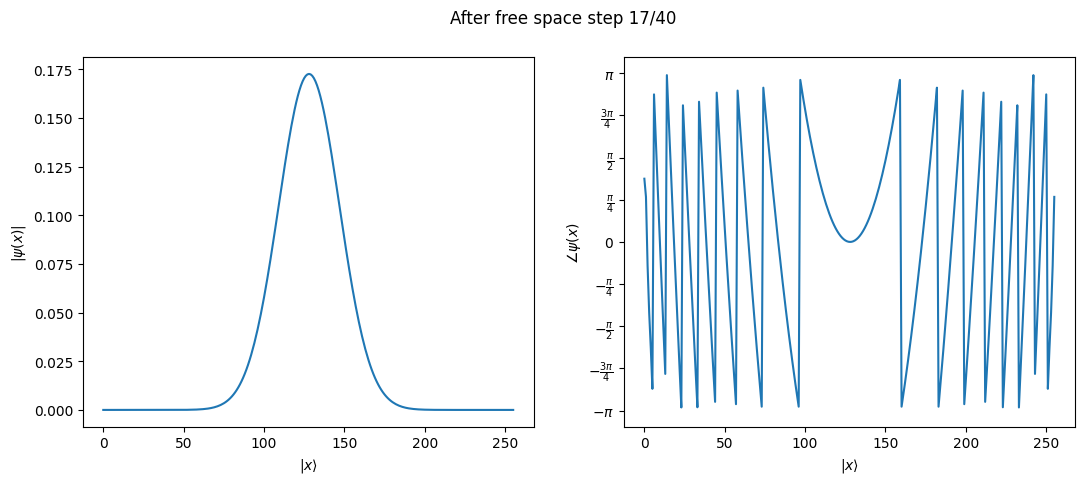

Plotting free space step 18/40


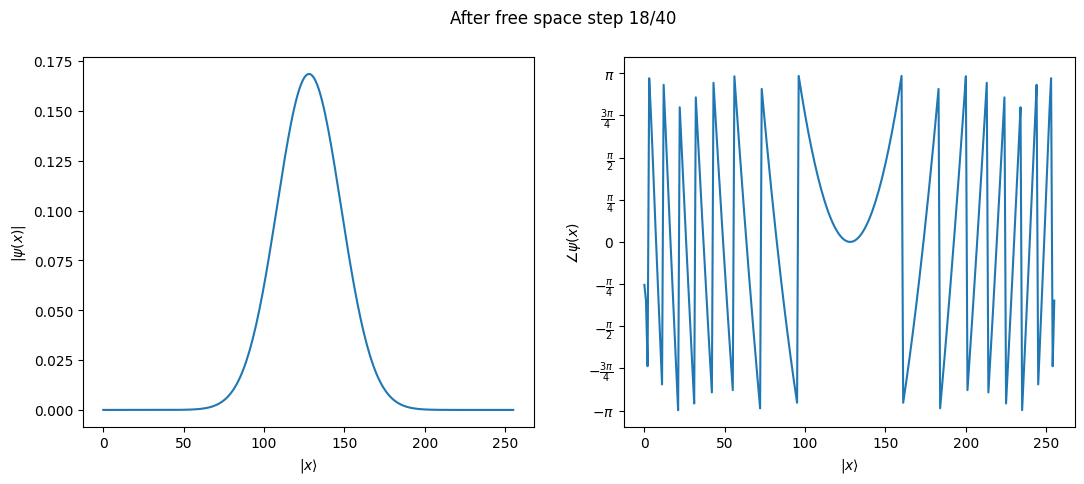

Plotting free space step 19/40


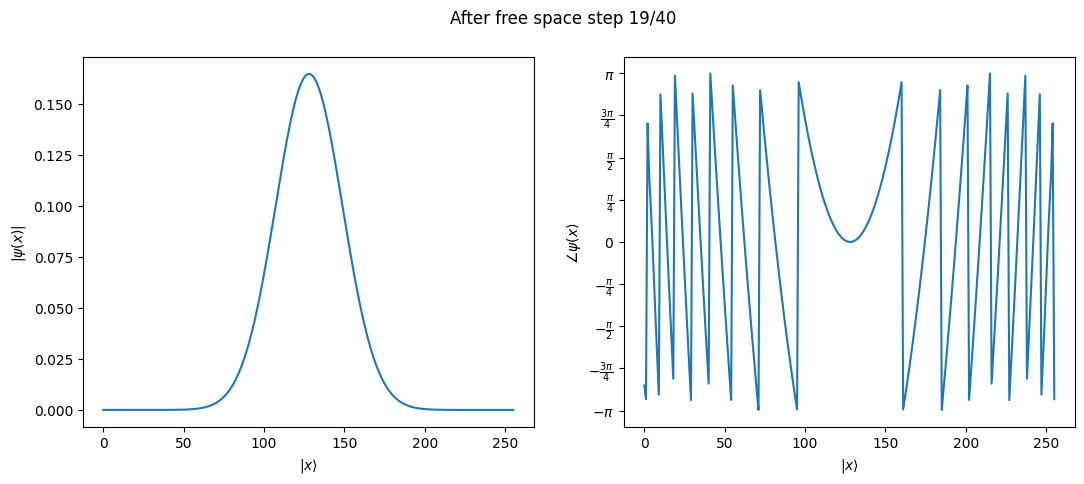

Plotting free space step 20/40


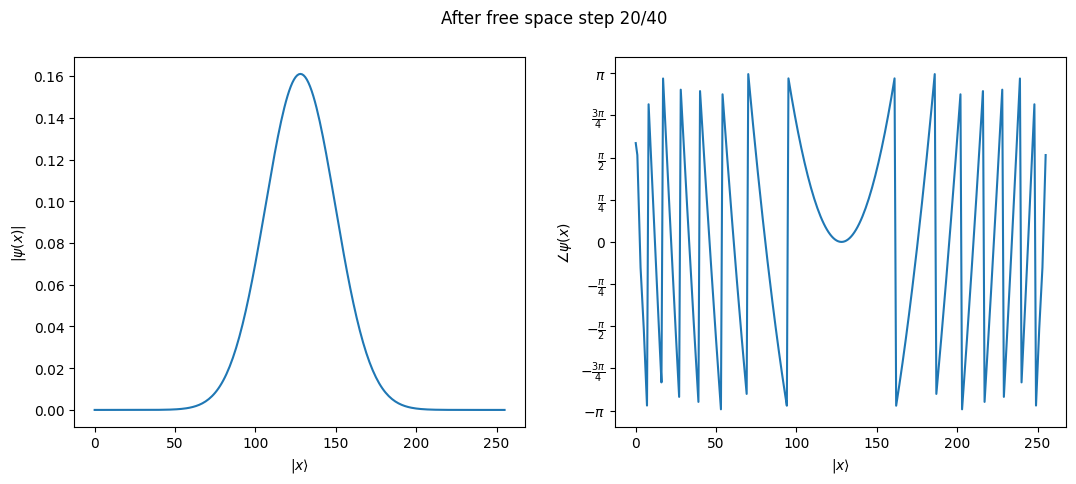

Plotting free space step 21/40


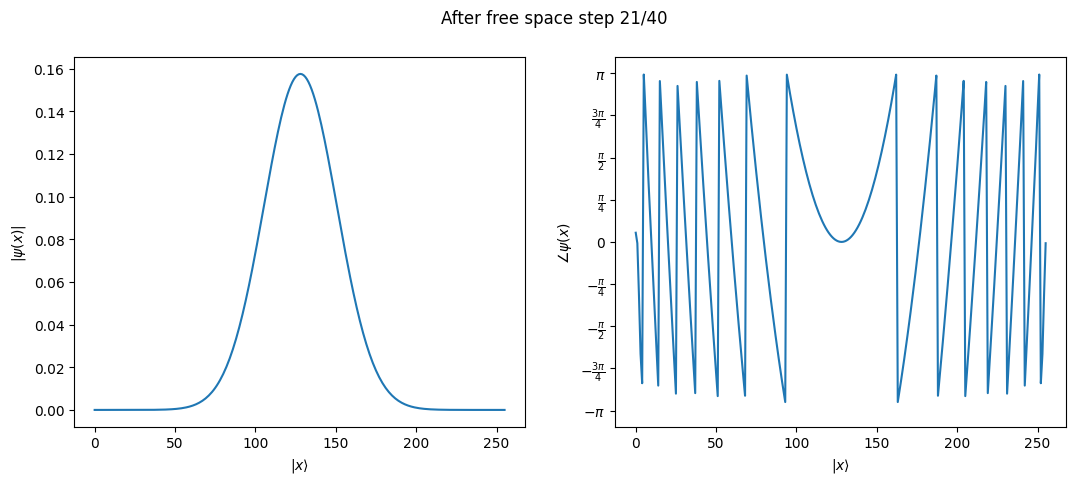

Plotting free space step 22/40


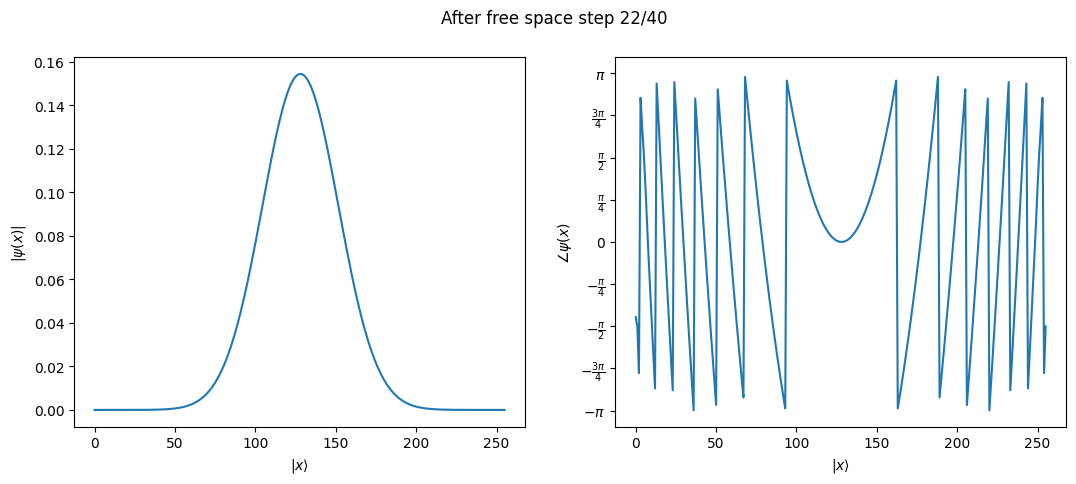

Plotting free space step 23/40


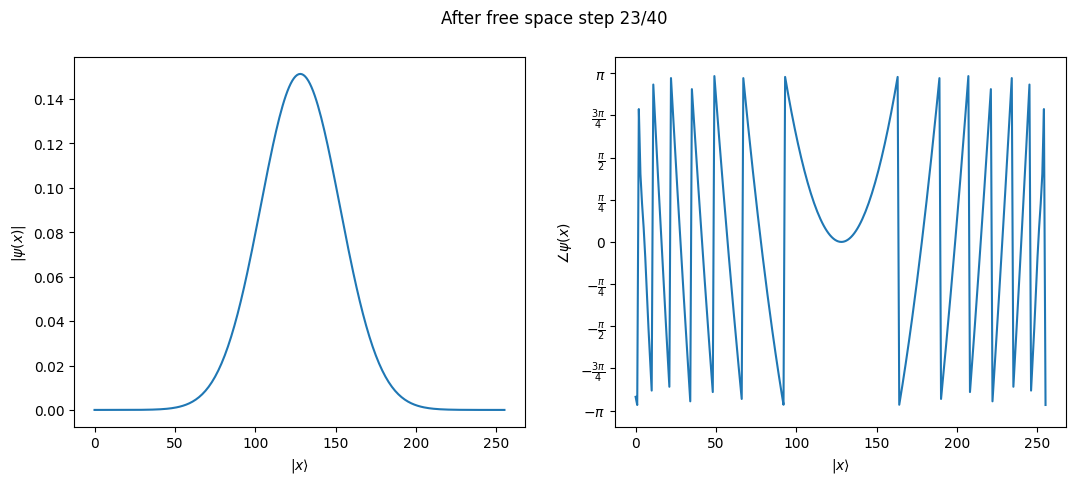

Plotting free space step 24/40


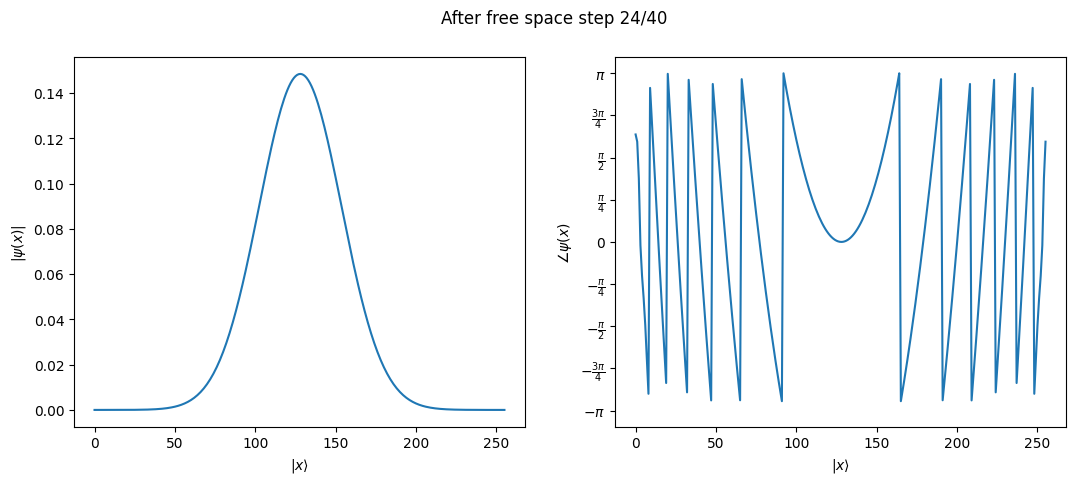

Plotting free space step 25/40


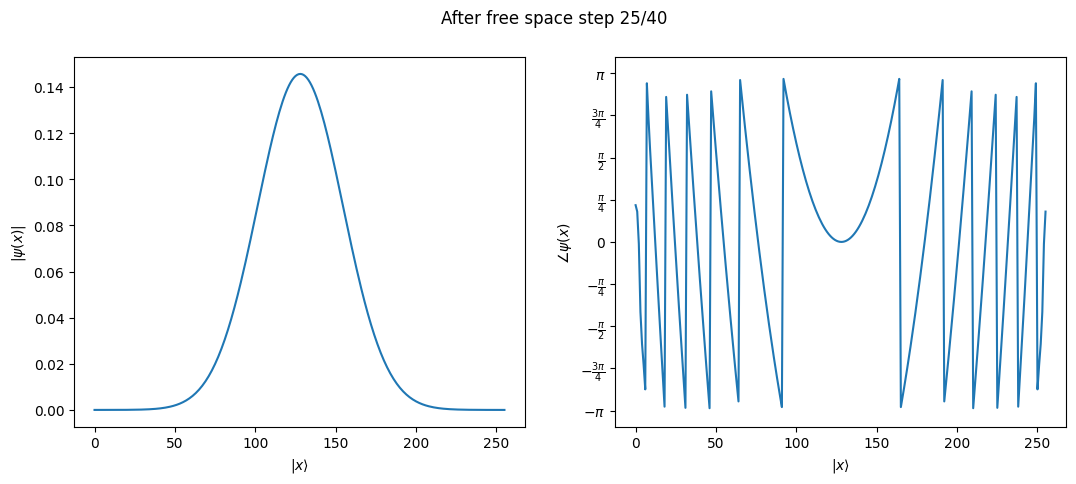

Plotting free space step 26/40


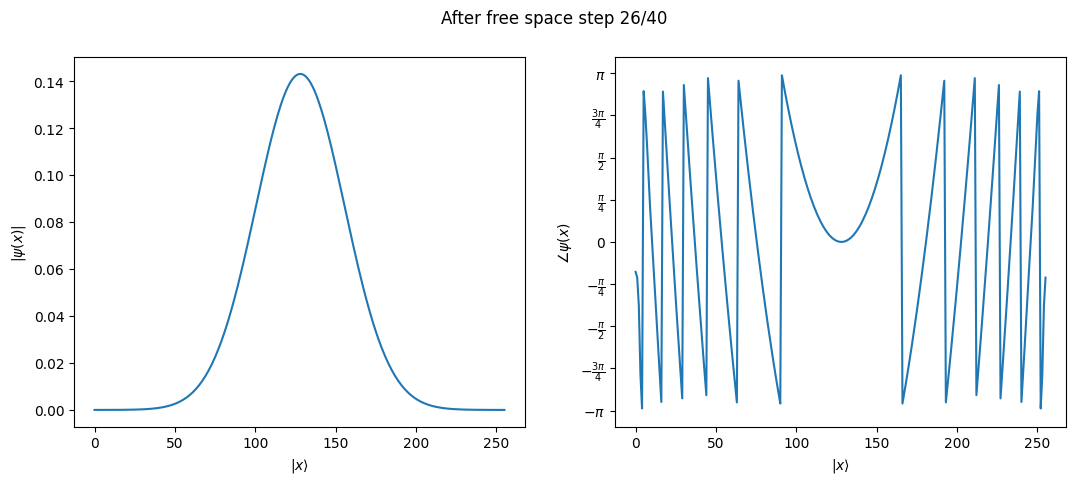

Plotting free space step 27/40


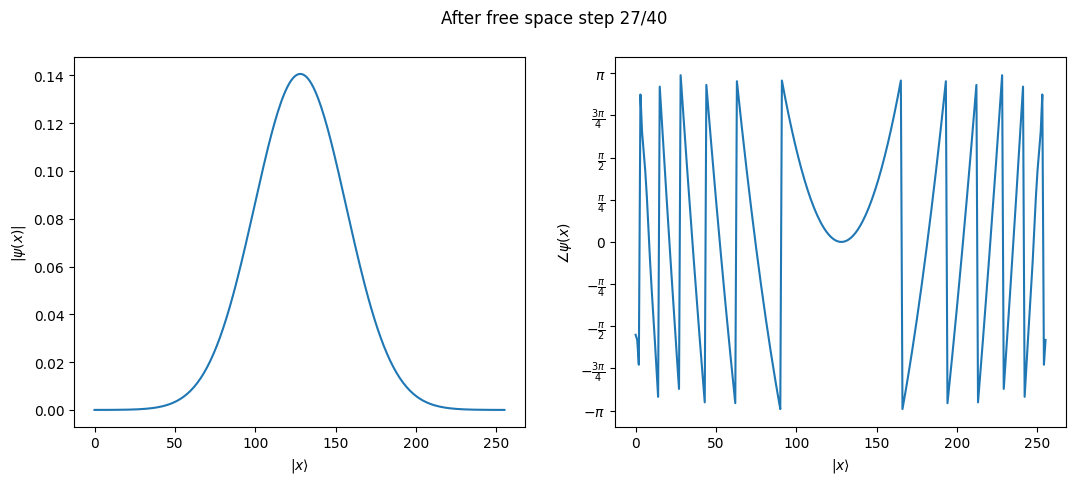

Plotting free space step 28/40


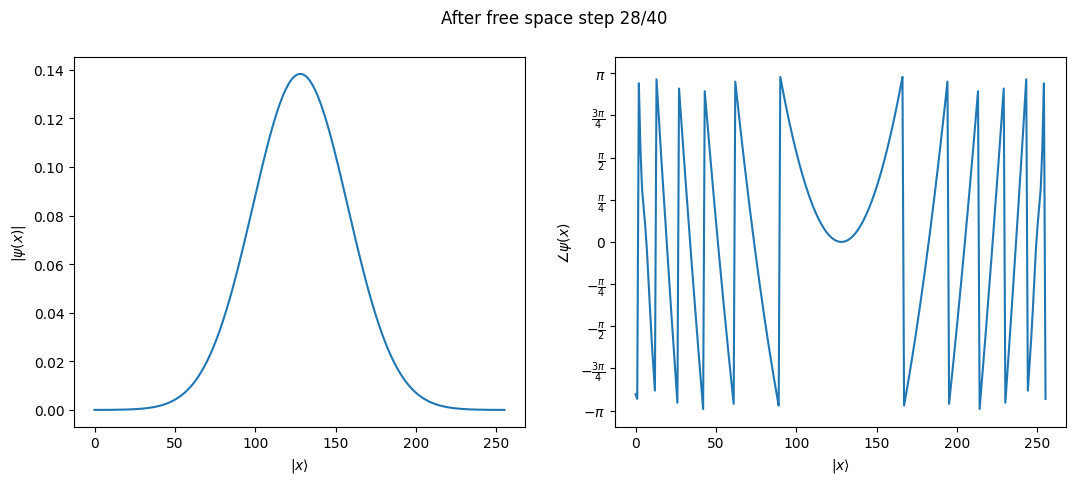

Plotting free space step 29/40


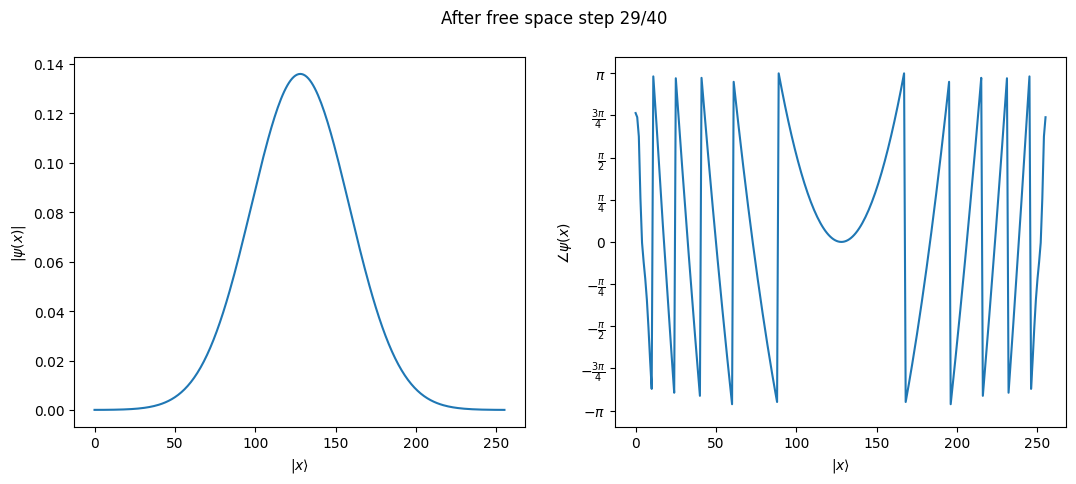

Plotting free space step 30/40


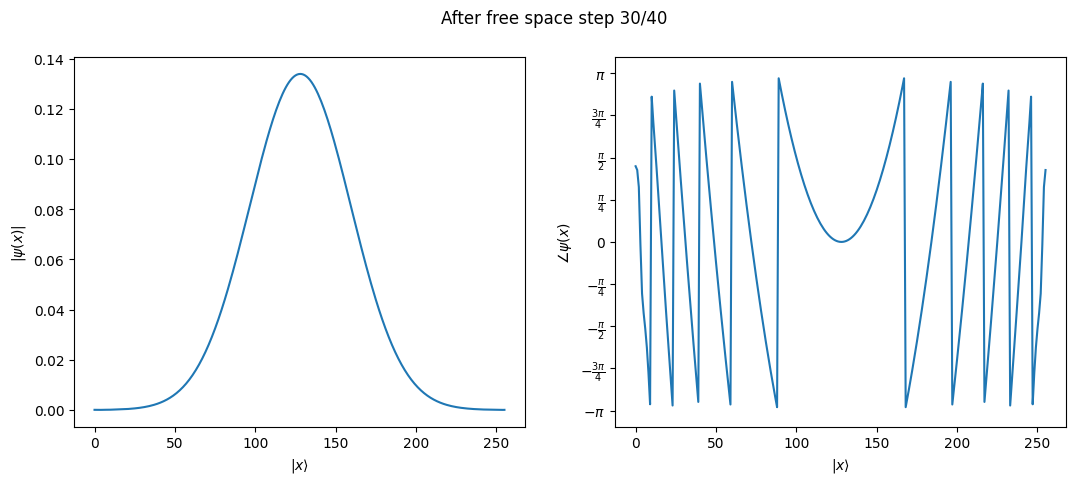

Plotting free space step 31/40


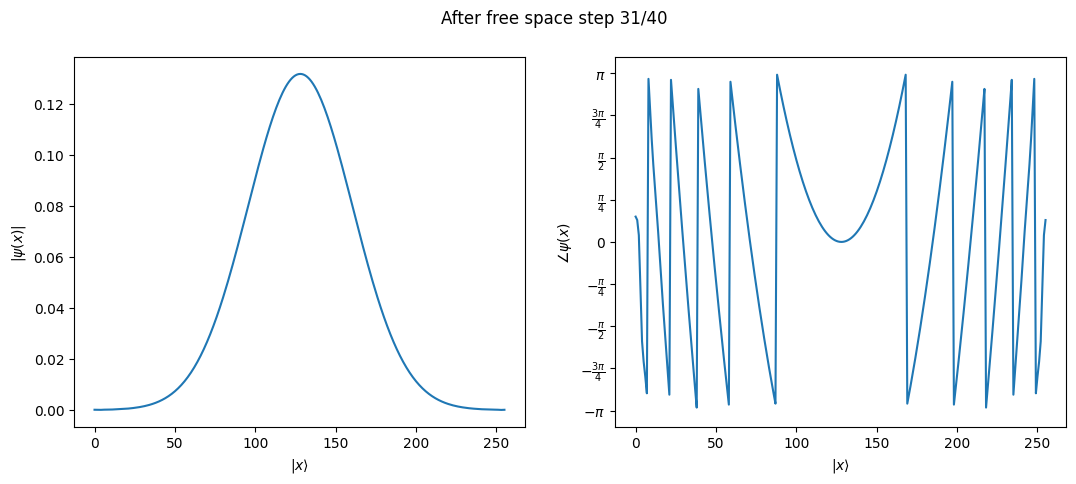

Plotting free space step 32/40


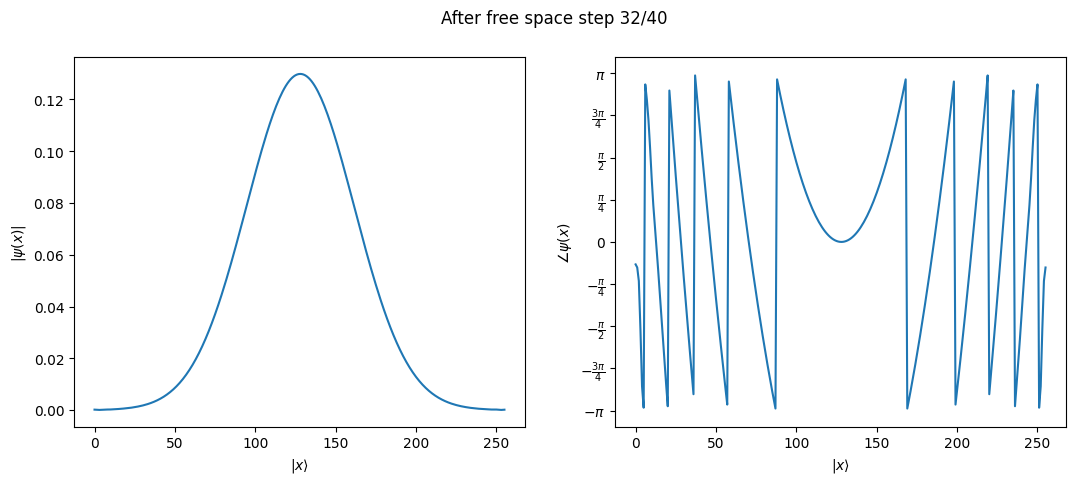

Plotting free space step 33/40


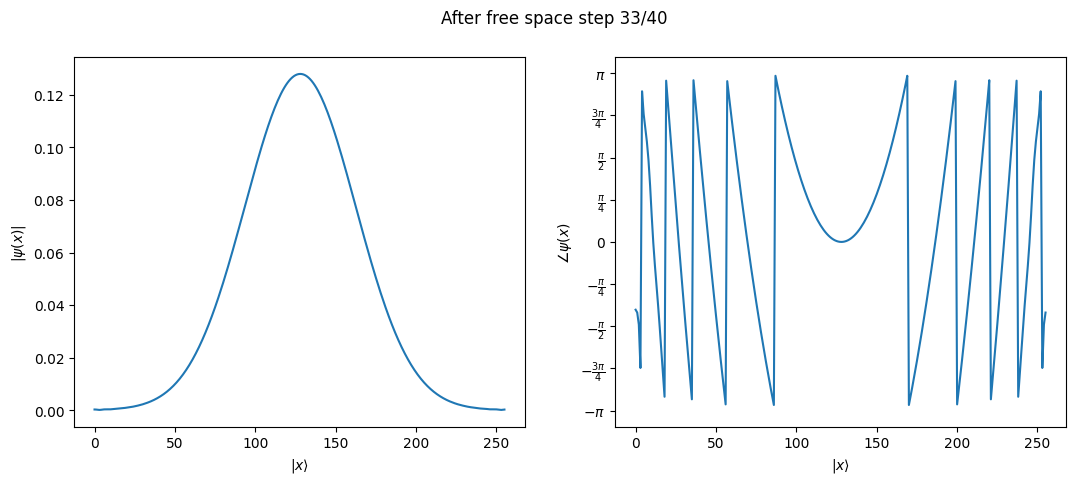

Plotting free space step 34/40


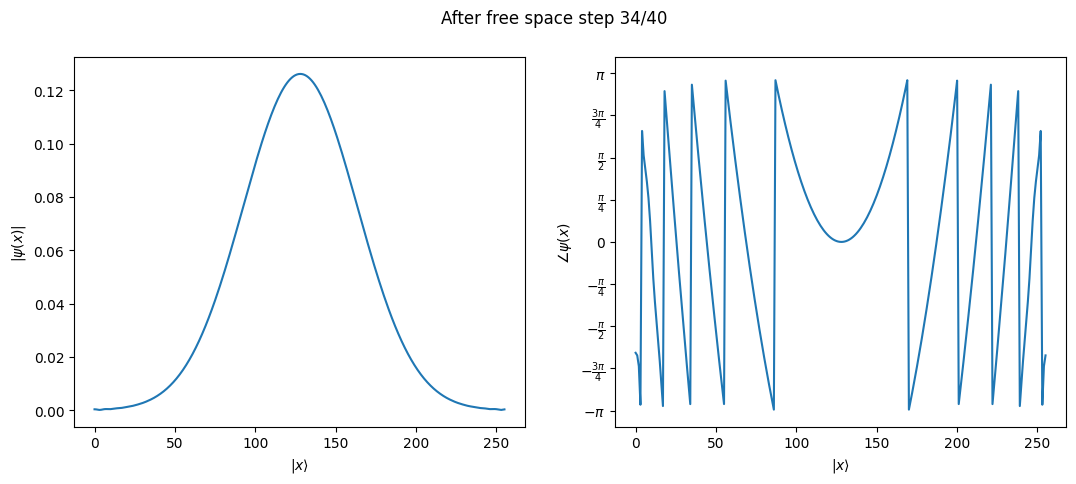

Plotting free space step 35/40


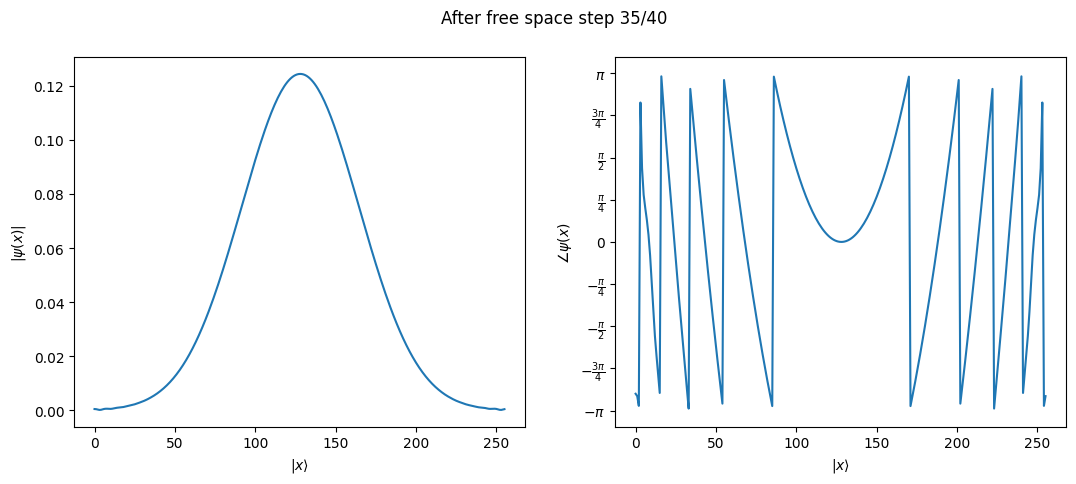

Plotting free space step 36/40


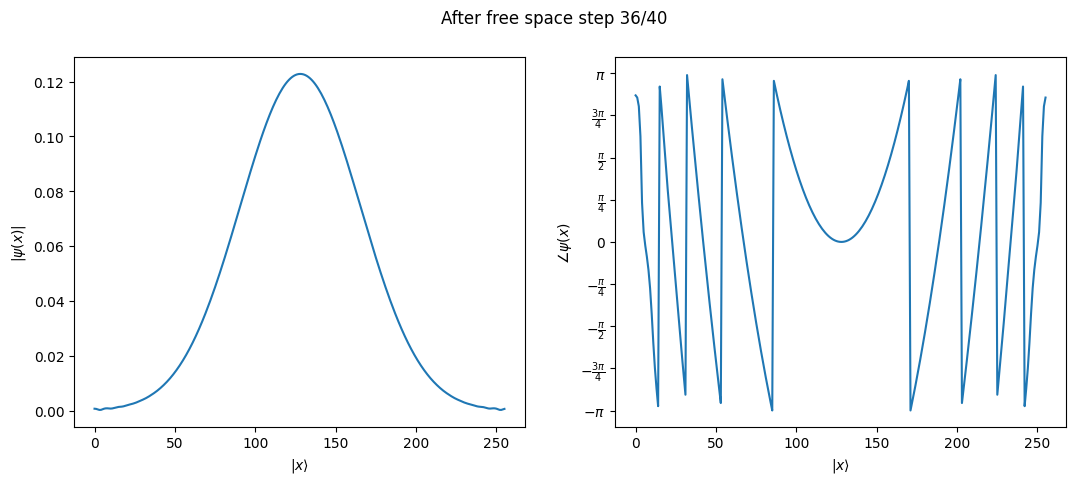

Plotting free space step 37/40


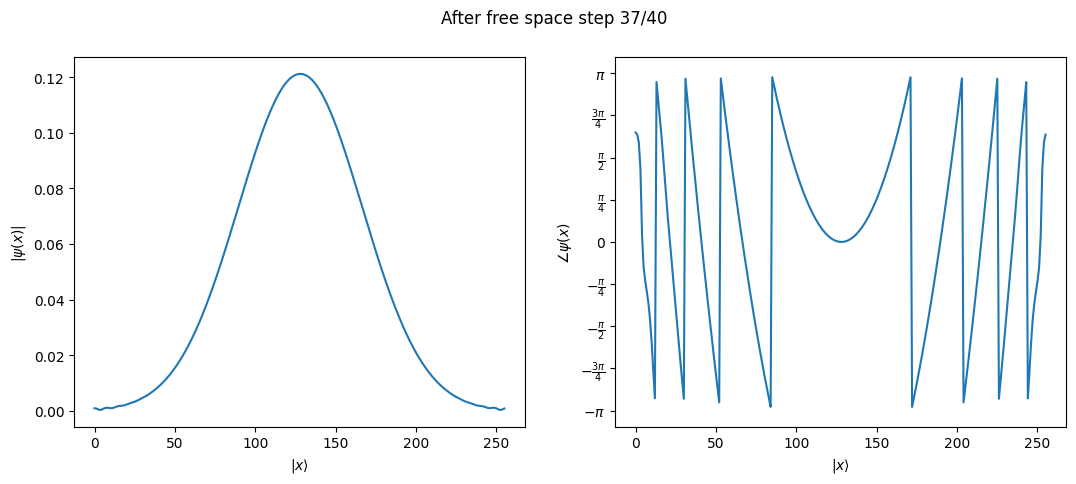

Plotting free space step 38/40


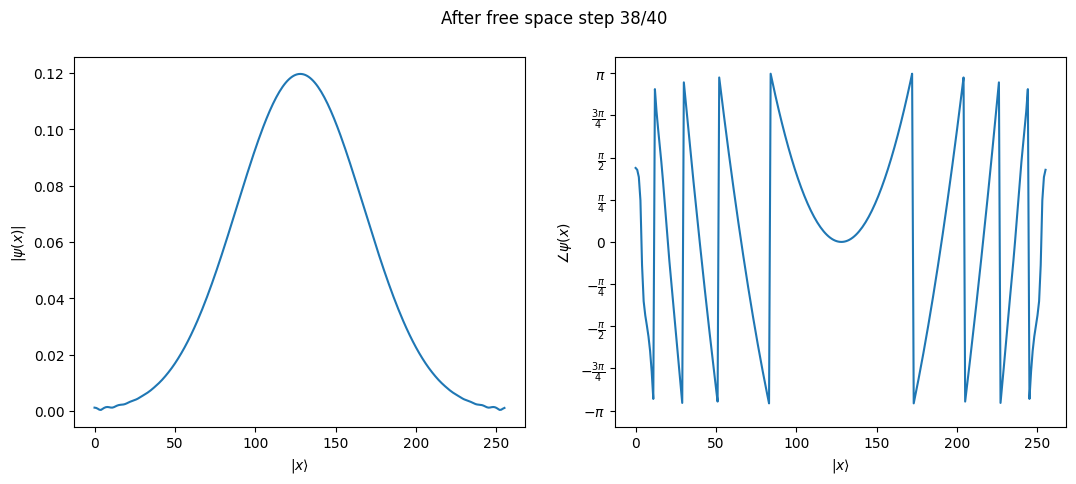

Plotting free space step 39/40


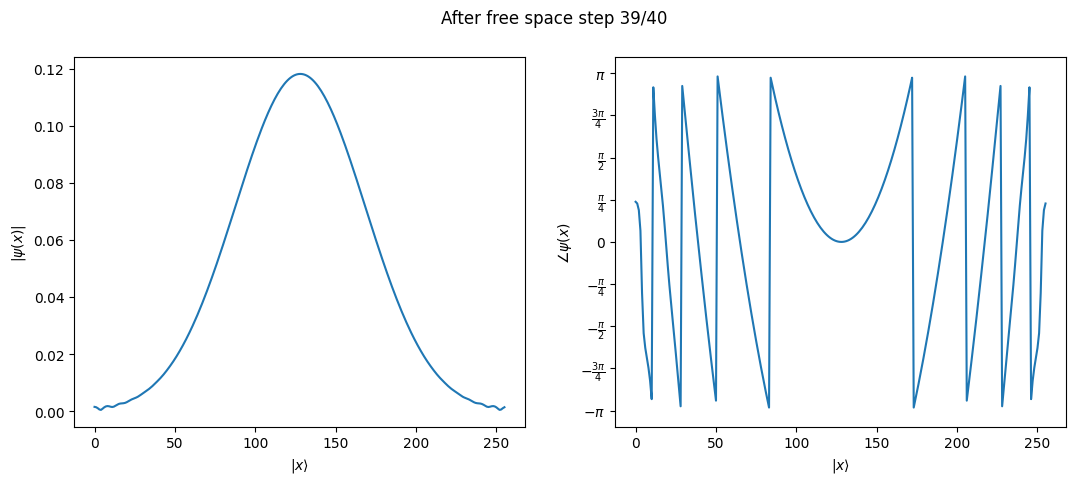

Plotting free space step 40/40


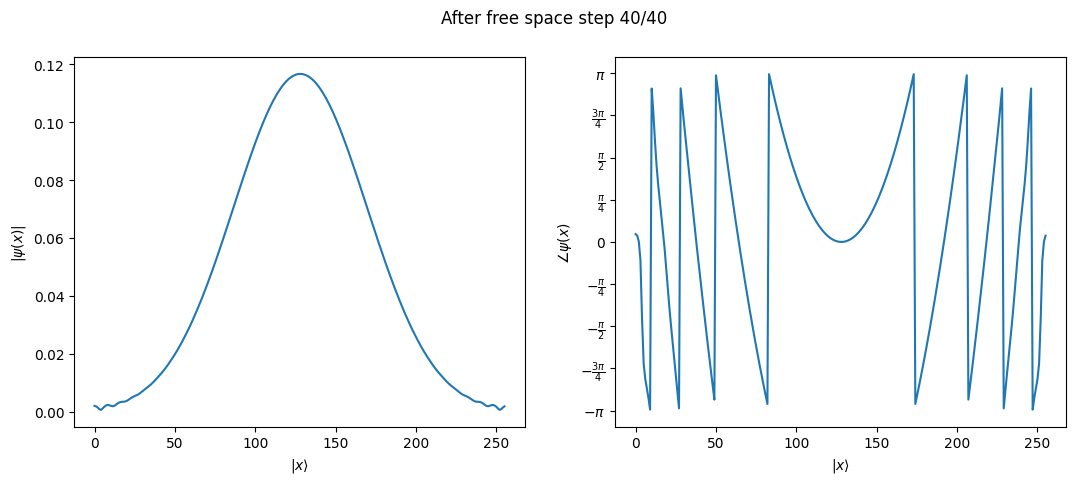

In [38]:
print("Plotting initial state")
plot_wavefunction(initial_statevector, plot_size_scale=1, normalize=True)
plt.suptitle("Initial state")
plt.show()

for i, statevector in enumerate(lens_statevectors):
    if statevector is None:
        continue
    print(f"Plotting lens slice {i + 1}/{lens_slices}")
    plot_wavefunction(statevector, plot_size_scale=1, normalize=True)
    plt.suptitle(f"After lens slice {i + 1}/{lens_slices}")
    plt.show()

for i, statevector in enumerate(after_lens_statevectors):
    if statevector is None:
        continue
    print(f"Plotting free space step {i + 1}/{num_of_steps_after_lens}")
    plot_wavefunction(statevector, plot_size_scale=1, normalize=True)
    plt.suptitle(f"After free space step {i + 1}/{num_of_steps_after_lens}")
    plt.show()